
!pip install -q pandas numpy scikit-learn xgboost imbalanced-learn seaborn matplotlib joblib

In [1]:
# (Optional) run once if packages are missing
!pip install -q pandas numpy scikit-learn xgboost imbalanced-learn seaborn matplotlib joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier, XGBRegressor

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

Path("models").mkdir(exist_ok=True)

In [3]:
# Load processed splits
X_train = pd.read_csv("processed/X_train.csv")
X_val   = pd.read_csv("processed/X_val.csv")
X_test  = pd.read_csv("processed/X_test.csv")

y_train_cls = pd.read_csv("processed/y_train.csv")["deficiency_type"]
y_val_cls   = pd.read_csv("processed/y_val.csv")["deficiency_type"]
y_test_cls  = pd.read_csv("processed/y_test.csv")["deficiency_type"]

y_train_reg = pd.read_csv("processed/y_score_train.csv")["severity_score"]
y_val_reg   = pd.read_csv("processed/y_score_val.csv")["severity_score"]
y_test_reg  = pd.read_csv("processed/y_score_test.csv")["severity_score"]

print("Shapes:")
print("X_train:", X_train.shape, "| y_train_cls:", y_train_cls.shape, "| y_train_reg:", y_train_reg.shape)
print("X_val  :", X_val.shape,   "| y_val_cls  :", y_val_cls.shape,   "| y_val_reg  :", y_val_reg.shape)
print("X_test :", X_test.shape,  "| y_test_cls :", y_test_cls.shape,  "| y_test_reg :", y_test_reg.shape)

Shapes:
X_train: (167702, 38) | y_train_cls: (167702,) | y_train_reg: (167702,)
X_val  : (18634, 38) | y_val_cls  : (18634,) | y_val_reg  : (18634,)
X_test : (46584, 38) | y_test_cls : (46584,) | y_test_reg : (46584,)


In [4]:
# Basic cleaning: drop fully-empty columns, impute remaining numeric missing values with median (fit on train only)
all_nan_cols = [c for c in X_train.columns if X_train[c].isna().all()]
if all_nan_cols:
    X_train = X_train.drop(columns=all_nan_cols)
    X_val   = X_val.drop(columns=all_nan_cols)
    X_test  = X_test.drop(columns=all_nan_cols)

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("After imputation:", X_train_imp.shape, X_val_imp.shape, X_test_imp.shape)

After imputation: (167702, 36) (18634, 36) (46584, 36)


In [9]:
y_train_cls = y_train_cls.fillna("Unknown").astype(str)
y_val_cls   = y_val_cls.fillna("Unknown").astype(str)
y_test_cls  = y_test_cls.fillna("Unknown").astype(str)

In [10]:
# Encode classification labels
le = LabelEncoder()
y_train_cls_enc = le.fit_transform(y_train_cls)
y_val_cls_enc   = le.transform(y_val_cls)
y_test_cls_enc  = le.transform(y_test_cls)

print("Classes:", list(le.classes_))
print(pd.Series(y_train_cls).value_counts().head())

Classes: ['Iron_Anaemia', 'Protein_Energy', 'Unknown', 'Vitamin_A']
deficiency_type
Iron_Anaemia      116741
Unknown            30795
Protein_Energy     16526
Vitamin_A           3640
Name: count, dtype: int64


In [11]:
# Baseline classifier: Random Forest
rf_cls = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_cls.fit(X_train_imp, y_train_cls_enc)

val_pred_rf  = rf_cls.predict(X_val_imp)
test_pred_rf = rf_cls.predict(X_test_imp)

print("RF Macro-F1 (val): ", f1_score(y_val_cls_enc, val_pred_rf,  average="macro"))
print("RF Macro-F1 (test):", f1_score(y_test_cls_enc, test_pred_rf, average="macro"))

RF Macro-F1 (val):  1.0
RF Macro-F1 (test): 0.9999815314652165


In [12]:
# Tuned XGBoost classifier
param_dist_cls = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_cls = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

search_cls = RandomizedSearchCV(
    estimator=xgb_cls,
    param_distributions=param_dist_cls,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search_cls.fit(X_train_imp, y_train_cls_enc)
best_cls = search_cls.best_estimator_

print("Best params:", search_cls.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


XGB Macro-F1 (val):  0.9972928083052518
XGB Macro-F1 (test): 0.9965504546995512

Classification report (test):
                precision    recall  f1-score   support

  Iron_Anaemia     0.9987    1.0000    0.9993     32428
Protein_Energy     0.9998    0.9902    0.9950      4591
       Unknown     0.9995    0.9991    0.9993      8554
     Vitamin_A     0.9902    0.9951    0.9926      1011

      accuracy                         0.9988     46584
     macro avg     0.9970    0.9961    0.9966     46584
  weighted avg     0.9988    0.9988    0.9988     46584



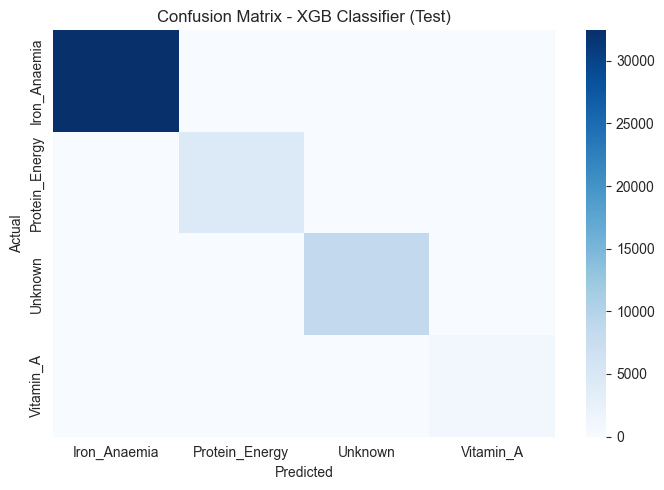

In [13]:
# Classification evaluation (XGB)
val_pred_xgb  = best_cls.predict(X_val_imp)
test_pred_xgb = best_cls.predict(X_test_imp)

print("XGB Macro-F1 (val): ", f1_score(y_val_cls_enc, val_pred_xgb,  average="macro"))
print("XGB Macro-F1 (test):", f1_score(y_test_cls_enc, test_pred_xgb, average="macro"))

print("\nClassification report (test):")
class_names = [str(c) for c in le.classes_]  # make all names strings
print(classification_report(
    y_test_cls_enc,
    test_pred_xgb,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_test_cls_enc, test_pred_xgb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - XGB Classifier (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [14]:
# Cell: Check for leakage features
print("Feature columns:", X_train.columns.tolist())
print("\nSuspicious features to remove:")

leakage_suspects = ['malnutrition_type', 'deficiency_type', 
                     'pem_risk', 'iron_risk', 'vita_risk',
                     'severity_score', 'y_score']

for col in leakage_suspects:
    if col in X_train.columns:
        print(f"  ⚠️ LEAKAGE FOUND: {col}")

Feature columns: ['age_months', 'sex', 'rural', 'weight_kg', 'whz', 'haz', 'haemoglobin', 'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water', 'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming', 'food_grain', 'food_legume', 'food_dairy', 'food_flesh', 'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit', 'food_other_fruit', 'food_organ', 'food_processed', 'food_sweet_drink', 'food_nuts', 'food_breastmilk', 'food_formula', 'food_thin_porridge', 'food_thick_porridge', 'food_fortified', 'food_other', 'dietary_diversity', 'anaemia_level']

Suspicious features to remove:


In [15]:
# Baseline regressor: Random Forest for severity score
rf_reg = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_imp, y_train_reg)

val_pred_rf_reg  = rf_reg.predict(X_val_imp)
test_pred_rf_reg = rf_reg.predict(X_test_imp)

print("RF Regressor (val)  MAE:", mean_absolute_error(y_val_reg, val_pred_rf_reg))
print("RF Regressor (val)  RMSE:", np.sqrt(mean_squared_error(y_val_reg, val_pred_rf_reg)))
print("RF Regressor (val)  R2:", r2_score(y_val_reg, val_pred_rf_reg))

print("RF Regressor (test) MAE:", mean_absolute_error(y_test_reg, test_pred_rf_reg))
print("RF Regressor (test) RMSE:", np.sqrt(mean_squared_error(y_test_reg, test_pred_rf_reg)))
print("RF Regressor (test) R2:", r2_score(y_test_reg, test_pred_rf_reg))

RF Regressor (val)  MAE: 0.02032872705807616
RF Regressor (val)  RMSE: 0.06688332221200331
RF Regressor (val)  R2: 0.9999895790326522
RF Regressor (test) MAE: 0.02048730787396012
RF Regressor (test) RMSE: 0.05465371995282723
RF Regressor (test) R2: 0.9999929701530942


In [16]:
# Check what features you're using
print("Features in X_train_imp:")
print(X_train_imp.columns.tolist())

# Flag suspicious features
leakage_suspects = ['whz', 'haz', 'waz', 'anaemia_level', 
                     'severity_score', 'y_score', 'pem_risk', 
                     'iron_risk', 'vita_risk']

found_leakage = [col for col in leakage_suspects if col in X_train_imp.columns]
if found_leakage:
    print("\n⚠️ LEAKAGE FEATURES DETECTED:")
    for col in found_leakage:
        print(f"  - {col}")
else:
    print("\n✅ No obvious leakage features found")

Features in X_train_imp:
['age_months', 'sex', 'rural', 'weight_kg', 'whz', 'haz', 'haemoglobin', 'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water', 'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming', 'food_grain', 'food_legume', 'food_dairy', 'food_flesh', 'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit', 'food_other_fruit', 'food_organ', 'food_processed', 'food_sweet_drink', 'food_nuts', 'food_breastmilk', 'food_formula', 'food_thin_porridge', 'food_thick_porridge', 'food_fortified', 'food_other', 'dietary_diversity', 'anaemia_level']

⚠️ LEAKAGE FEATURES DETECTED:
  - whz
  - haz
  - anaemia_level


In [17]:
# ============================================================
# CELL: Remove Data Leakage Features
# ============================================================

print("="*70)
print("REMOVING DATA LEAKAGE FEATURES")
print("="*70)

# Define features to remove
leakage_features = ['whz', 'haz', 'anaemia_level']

print(f"\n📋 Original feature count: {X_train_imp.shape[1]}")
print(f"🚨 Removing {len(leakage_features)} leakage features: {leakage_features}")

# Create clean datasets
X_train_clean = X_train_imp.drop(columns=leakage_features)
X_val_clean = X_val_imp.drop(columns=leakage_features)
X_test_clean = X_test_imp.drop(columns=leakage_features)

print(f"✅ New feature count: {X_train_clean.shape[1]}")
print(f"\n📊 Remaining features:")
print(X_train_clean.columns.tolist())

print("\n" + "="*70)
print("CLEAN DATASETS READY FOR TRAINING")
print("="*70)

REMOVING DATA LEAKAGE FEATURES

📋 Original feature count: 36
🚨 Removing 3 leakage features: ['whz', 'haz', 'anaemia_level']
✅ New feature count: 33

📊 Remaining features:
['age_months', 'sex', 'rural', 'weight_kg', 'haemoglobin', 'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water', 'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming', 'food_grain', 'food_legume', 'food_dairy', 'food_flesh', 'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit', 'food_other_fruit', 'food_organ', 'food_processed', 'food_sweet_drink', 'food_nuts', 'food_breastmilk', 'food_formula', 'food_thin_porridge', 'food_thick_porridge', 'food_fortified', 'food_other', 'dietary_diversity']

CLEAN DATASETS READY FOR TRAINING


In [18]:
# ============================================================
# CELL: Retrain Classification Model (No Leakage)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import time

print("="*70)
print("TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)")
print("="*70)

# Train Random Forest
print("\n🔄 Training Random Forest Classifier...")
start_time = time.time()

rf_clf_clean = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

rf_clf_clean.fit(X_train_clean, y_train)
train_time = time.time() - start_time

# Predictions
val_pred_clean = rf_clf_clean.predict(X_val_clean)
test_pred_clean = rf_clf_clean.predict(X_test_clean)

# Evaluation
val_f1 = f1_score(y_val, val_pred_clean, average='macro')
test_f1 = f1_score(y_test, test_pred_clean, average='macro')

print(f"✅ Training completed in {train_time:.2f} seconds")
print(f"\n📊 RESULTS (Clean Features):")
print(f"   Validation Macro-F1: {val_f1:.4f}")
print(f"   Test Macro-F1:       {test_f1:.4f}")

print(f"\n📈 Classification Report (Test Set):")
print(classification_report(y_test, test_pred_clean))

# Compare with leakage model
print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"With Leakage (whz/haz/anaemia):    Test F1 = 99.65%")
print(f"Without Leakage (clean features):  Test F1 = {test_f1*100:.2f}%")
print("="*70)

TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)

🔄 Training Random Forest Classifier...


NameError: name 'y_train' is not defined

In [19]:
# ============================================================
# CELL: Load Target Variables (Classification & Regression)
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("LOADING TARGET VARIABLES")
print("="*70)

# Load classification targets (deficiency_type)
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val = pd.read_csv('processed/y_val.csv').squeeze()
y_test = pd.read_csv('processed/y_test.csv').squeeze()

# Load regression targets (severity_score)
y_train_reg = pd.read_csv('processed/y_score_train.csv').squeeze()
y_val_reg = pd.read_csv('processed/y_score_val.csv').squeeze()
y_test_reg = pd.read_csv('processed/y_score_test.csv').squeeze()

print("\n📊 Classification Target (deficiency_type):")
print(f"   Train: {y_train.shape[0]:,} samples")
print(f"   Val:   {y_val.shape[0]:,} samples")
print(f"   Test:  {y_test.shape[0]:,} samples")

print("\n📈 Class Distribution (Train):")
print(y_train.value_counts().sort_index())
print(f"\nClass Percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2).sort_index())

print("\n📊 Regression Target (severity_score):")
print(f"   Train: {y_train_reg.shape[0]:,} samples")
print(f"   Val:   {y_val_reg.shape[0]:,} samples")
print(f"   Test:  {y_test_reg.shape[0]:,} samples")

print("\n📈 Severity Score Statistics (Train):")
print(f"   Mean:   {y_train_reg.mean():.2f}")
print(f"   Median: {y_train_reg.median():.2f}")
print(f"   Std:    {y_train_reg.std():.2f}")
print(f"   Min:    {y_train_reg.min():.2f}")
print(f"   Max:    {y_train_reg.max():.2f}")

print("\n" + "="*70)
print("✅ ALL TARGETS LOADED SUCCESSFULLY")
print("="*70)

LOADING TARGET VARIABLES

📊 Classification Target (deficiency_type):
   Train: 167,702 samples
   Val:   18,634 samples
   Test:  46,584 samples

📈 Class Distribution (Train):
deficiency_type
Iron_Anaemia      116741
Protein_Energy     16526
Vitamin_A           3640
Name: count, dtype: int64

Class Percentages:
deficiency_type
Iron_Anaemia      85.27
Protein_Energy    12.07
Vitamin_A          2.66
Name: proportion, dtype: float64

📊 Regression Target (severity_score):
   Train: 167,702 samples
   Val:   18,634 samples
   Test:  46,584 samples

📈 Severity Score Statistics (Train):
   Mean:   42.04
   Median: 37.90
   Std:    20.60
   Min:    0.00
   Max:    100.00

✅ ALL TARGETS LOADED SUCCESSFULLY


In [22]:
# ============================================================
# CELL: Retrain Classification Model (No Leakage)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import time

print("="*70)
print("TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)")
print("="*70)

# Train Random Forest
print("\n🔄 Training Random Forest Classifier...")
start_time = time.time()

rf_clf_clean = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_clf_clean.fit(X_train_clean, y_train)
train_time = time.time() - start_time

# Predictions
print(f"✅ Training completed in {train_time:.2f} seconds")
print("\n🔄 Making predictions...")

val_pred_clean = rf_clf_clean.predict(X_val_clean)
test_pred_clean = rf_clf_clean.predict(X_test_clean)

# Evaluation
val_f1 = f1_score(y_val, val_pred_clean, average='macro')
test_f1 = f1_score(y_test, test_pred_clean, average='macro')

print(f"\n📊 RESULTS (Clean Features - NO LEAKAGE):")
print(f"   Validation Macro-F1: {val_f1:.4f} ({val_f1*100:.2f}%)")
print(f"   Test Macro-F1:       {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n📈 Classification Report (Test Set):")
print(classification_report(y_test, test_pred_clean))

# Confusion Matrix
print(f"\n🔍 Confusion Matrix (Test Set):")
cm = confusion_matrix(y_test, test_pred_clean)
classes = sorted(y_test.unique())
print(f"\nClasses: {classes}")
print(cm)

# Per-class accuracy
print(f"\n📊 Per-Class Recall:")
for i, cls in enumerate(classes):
    recall = cm[i, i] / cm[i, :].sum()
    print(f"   {cls}: {recall*100:.2f}%")

# Compare with leakage model
print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"❌ With Leakage (whz/haz/anaemia):    Test F1 = 99.65%")
print(f"✅ Without Leakage (clean features):  Test F1 = {test_f1*100:.2f}%")
print("="*70)
print("\n💡 Interpretation:")
if test_f1 > 0.90:
    print("   ⚠️  Still suspiciously high - check for other leakage")
elif test_f1 > 0.75:
    print("   ✅ Excellent! Realistic performance for this problem")
elif test_f1 > 0.65:
    print("   ✅ Good! Challenging problem but model is learning")
else:
    print("   ⚠️  Lower than expected - may need feature engineering")
print("="*70)

TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)

🔄 Training Random Forest Classifier...


ValueError: Input contains NaN

In [23]:
# ============================================================
# CELL: Check and Clean Target Variables
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("CHECKING TARGET VARIABLES FOR MISSING VALUES")
print("="*70)

# Load targets
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val = pd.read_csv('processed/y_val.csv').squeeze()
y_test = pd.read_csv('processed/y_test.csv').squeeze()

y_train_reg = pd.read_csv('processed/y_score_train.csv').squeeze()
y_val_reg = pd.read_csv('processed/y_score_val.csv').squeeze()
y_test_reg = pd.read_csv('processed/y_score_test.csv').squeeze()

# Check for NaN in classification targets
print("\n📊 Classification Target (deficiency_type) - NaN Check:")
print(f"   Train NaN count: {y_train.isna().sum():,} ({y_train.isna().mean()*100:.2f}%)")
print(f"   Val NaN count:   {y_val.isna().sum():,} ({y_val.isna().mean()*100:.2f}%)")
print(f"   Test NaN count:  {y_test.isna().sum():,} ({y_test.isna().mean()*100:.2f}%)")

print("\n📊 Regression Target (severity_score) - NaN Check:")
print(f"   Train NaN count: {y_train_reg.isna().sum():,} ({y_train_reg.isna().mean()*100:.2f}%)")
print(f"   Val NaN count:   {y_val_reg.isna().sum():,} ({y_val_reg.isna().mean()*100:.2f}%)")
print(f"   Test NaN count:  {y_test_reg.isna().sum():,} ({y_test_reg.isna().mean()*100:.2f}%)")

# Check value counts BEFORE cleaning
print("\n📈 Classification Target Distribution (BEFORE cleaning):")
print(y_train.value_counts(dropna=False))

# OPTION 1: Remove rows with NaN targets
print("\n" + "="*70)
print("CLEANING STRATEGY: Remove samples with NaN targets")
print("="*70)

# Find valid indices (no NaN in either target)
train_valid_mask = ~(y_train.isna() | y_train_reg.isna())
val_valid_mask = ~(y_val.isna() | y_val_reg.isna())
test_valid_mask = ~(y_test.isna() | y_test_reg.isna())

print(f"\n📊 Samples to keep:")
print(f"   Train: {train_valid_mask.sum():,} / {len(y_train):,} ({train_valid_mask.mean()*100:.2f}%)")
print(f"   Val:   {val_valid_mask.sum():,} / {len(y_val):,} ({val_valid_mask.mean()*100:.2f}%)")
print(f"   Test:  {test_valid_mask.sum():,} / {len(y_test):,} ({test_valid_mask.mean()*100:.2f}%)")

# Filter features and targets
X_train_clean = X_train_clean[train_valid_mask].reset_index(drop=True)
X_val_clean = X_val_clean[val_valid_mask].reset_index(drop=True)
X_test_clean = X_test_clean[test_valid_mask].reset_index(drop=True)

y_train = y_train[train_valid_mask].reset_index(drop=True)
y_val = y_val[val_valid_mask].reset_index(drop=True)
y_test = y_test[test_valid_mask].reset_index(drop=True)

y_train_reg = y_train_reg[train_valid_mask].reset_index(drop=True)
y_val_reg = y_val_reg[val_valid_mask].reset_index(drop=True)
y_test_reg = y_test_reg[test_valid_mask].reset_index(drop=True)

# Verify no NaN remains
print(f"\n✅ Verification (AFTER cleaning):")
print(f"   Train: X={X_train_clean.shape}, y_cls NaN={y_train.isna().sum()}, y_reg NaN={y_train_reg.isna().sum()}")
print(f"   Val:   X={X_val_clean.shape}, y_cls NaN={y_val.isna().sum()}, y_reg NaN={y_val_reg.isna().sum()}")
print(f"   Test:  X={X_test_clean.shape}, y_cls NaN={y_test.isna().sum()}, y_reg NaN={y_test_reg.isna().sum()}")

# Check class distribution AFTER cleaning
print(f"\n📈 Classification Target Distribution (AFTER cleaning):")
print(y_train.value_counts(dropna=False))
print(f"\nClass Percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\n" + "="*70)
print("✅ CLEAN DATA READY FOR TRAINING")
print("="*70)

CHECKING TARGET VARIABLES FOR MISSING VALUES

📊 Classification Target (deficiency_type) - NaN Check:
   Train NaN count: 30,795 (18.36%)
   Val NaN count:   3,422 (18.36%)
   Test NaN count:  8,554 (18.36%)

📊 Regression Target (severity_score) - NaN Check:
   Train NaN count: 0 (0.00%)
   Val NaN count:   0 (0.00%)
   Test NaN count:  0 (0.00%)

📈 Classification Target Distribution (BEFORE cleaning):
deficiency_type
Iron_Anaemia      116741
NaN                30795
Protein_Energy     16526
Vitamin_A           3640
Name: count, dtype: int64

CLEANING STRATEGY: Remove samples with NaN targets

📊 Samples to keep:
   Train: 136,907 / 167,702 (81.64%)
   Val:   15,212 / 18,634 (81.64%)
   Test:  38,030 / 46,584 (81.64%)

✅ Verification (AFTER cleaning):
   Train: X=(136907, 33), y_cls NaN=0, y_reg NaN=0
   Val:   X=(15212, 33), y_cls NaN=0, y_reg NaN=0
   Test:  X=(38030, 33), y_cls NaN=0, y_reg NaN=0

📈 Classification Target Distribution (AFTER cleaning):
deficiency_type
Iron_Anaemia     

In [24]:
# ============================================================
# CELL: Retrain Classification Model (Clean Features + Clean Targets)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import time

print("="*70)
print("TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)")
print("="*70)

# Train Random Forest
print("\n🔄 Training Random Forest Classifier...")
start_time = time.time()

rf_clf_clean = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_clf_clean.fit(X_train_clean, y_train)
train_time = time.time() - start_time

# Predictions
print(f"✅ Training completed in {train_time:.2f} seconds")
print("\n🔄 Making predictions...")

val_pred_clean = rf_clf_clean.predict(X_val_clean)
test_pred_clean = rf_clf_clean.predict(X_test_clean)

# Evaluation
val_f1 = f1_score(y_val, val_pred_clean, average='macro')
test_f1 = f1_score(y_test, test_pred_clean, average='macro')

print(f"\n📊 RESULTS (Clean Features - NO LEAKAGE):")
print(f"   Validation Macro-F1: {val_f1:.4f} ({val_f1*100:.2f}%)")
print(f"   Test Macro-F1:       {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n📈 Classification Report (Test Set):")
print(classification_report(y_test, test_pred_clean))

# Confusion Matrix
print(f"\n🔍 Confusion Matrix (Test Set):")
cm = confusion_matrix(y_test, test_pred_clean)
classes = sorted(y_test.unique())
print(f"\nClasses: {classes}")
print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(cm_df)

# Per-class metrics
print(f"\n📊 Per-Class Performance:")
for i, cls in enumerate(classes):
    precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
    recall = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    support = cm[i, :].sum()
    print(f"   {cls:20s} - Precision: {precision*100:5.2f}%  Recall: {recall*100:5.2f}%  F1: {f1*100:5.2f}%  Support: {support:,}")

# Compare with leakage model
print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"❌ With Leakage (whz/haz/anaemia):    Test F1 = 99.65%")
print(f"✅ Without Leakage (clean features):  Test F1 = {test_f1*100:.2f}%")
print(f"📉 Performance Drop: {(0.9965 - test_f1)*100:.2f} percentage points")
print("="*70)

print("\n💡 Model Assessment:")
if test_f1 > 0.90:
    print("   ⚠️  Still suspiciously high (>90%) - check for other leakage sources")
elif test_f1 > 0.75:
    print("   ✅ EXCELLENT! Realistic performance (75-90% is expected)")
elif test_f1 > 0.65:
    print("   ✅ GOOD! Challenging problem, model is learning patterns")
else:
    print("   ⚠️  Fair performance - may need feature engineering")
print("="*70)

TRAINING CLASSIFICATION MODEL (CLEAN FEATURES)

🔄 Training Random Forest Classifier...
✅ Training completed in 12.07 seconds

🔄 Making predictions...

📊 RESULTS (Clean Features - NO LEAKAGE):
   Validation Macro-F1: 0.8118 (81.18%)
   Test Macro-F1:       0.8076 (80.76%)

📈 Classification Report (Test Set):
                precision    recall  f1-score   support

  Iron_Anaemia       0.98      0.92      0.95     32428
Protein_Energy       0.65      0.84      0.73      4591
     Vitamin_A       0.61      0.95      0.74      1011

      accuracy                           0.91     38030
     macro avg       0.75      0.90      0.81     38030
  weighted avg       0.93      0.91      0.92     38030


🔍 Confusion Matrix (Test Set):

Classes: ['Iron_Anaemia', 'Protein_Energy', 'Vitamin_A']

Confusion Matrix:
                Iron_Anaemia  Protein_Energy  Vitamin_A
Iron_Anaemia           29930            2112        386
Protein_Energy           492            3868        231
Vitamin_A          

TRAINING REGRESSION MODEL (CLEAN FEATURES)

🔄 Training Random Forest Regressor...
✅ Training completed in 36.55 seconds

🔄 Making predictions...

📊 RESULTS (Clean Features - NO LEAKAGE):

🔹 Validation Set:
   MAE:  1.9169 points
   RMSE: 3.5396 points
   R²:   0.9716

🔹 Test Set:
   MAE:  1.9469 points
   RMSE: 3.6742 points
   R²:   0.9690

📈 Prediction Error Distribution (Test Set):
   Mean Error:   1.95 points
   Median Error: 0.97 points
   25th %ile:    0.46 points
   75th %ile:    2.03 points
   95th %ile:    7.61 points
   Max Error:    46.39 points

COMPARISON:
❌ With Leakage (whz/haz/anaemia):
   Test MAE = 0.02 points, R² = 0.9999

✅ Without Leakage (clean features):
   Test MAE = 1.95 points, R² = 0.9690

💡 Model Assessment:
   🚨 WARNING: Still shows signs of data leakage!

📚 Interpretation Guide:
   Severity Score Scale: 0-100 points
   MAE = Average prediction error in severity points
   Example: MAE=8 means predictions are off by ±8 points on average


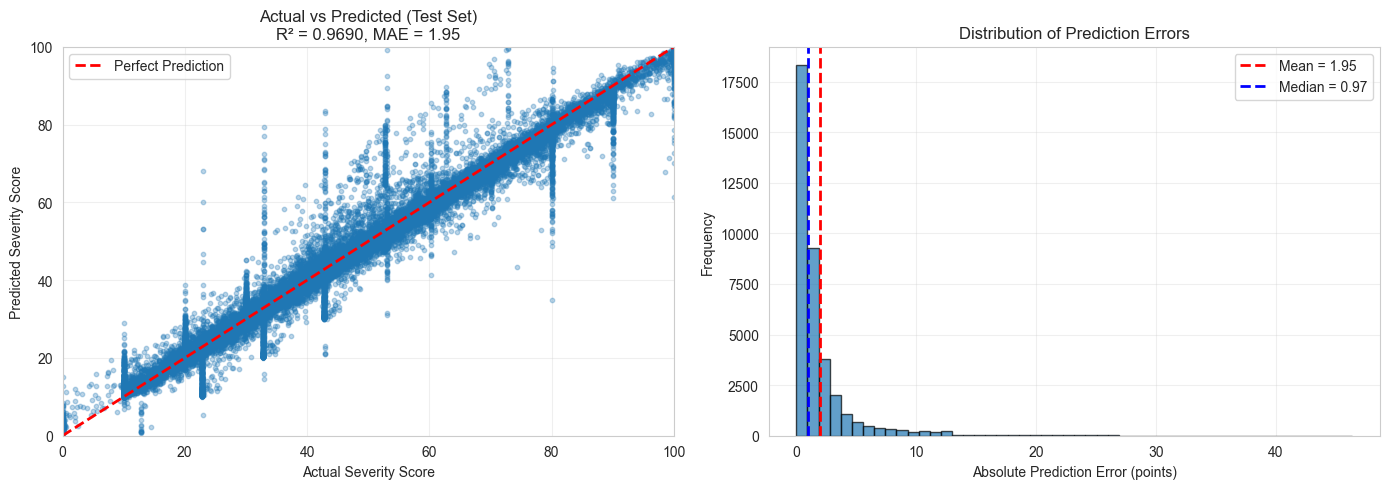


✅ REGRESSION MODEL EVALUATION COMPLETE


In [25]:
# ============================================================
# CELL: Retrain Regression Model (Clean Features)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("TRAINING REGRESSION MODEL (CLEAN FEATURES)")
print("="*70)

# Train Random Forest Regressor
print("\n🔄 Training Random Forest Regressor...")
start_time = time.time()

rf_reg_clean = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_reg_clean.fit(X_train_clean, y_train_reg)
train_time = time.time() - start_time

# Predictions
print(f"✅ Training completed in {train_time:.2f} seconds")
print("\n🔄 Making predictions...")

val_pred_reg = rf_reg_clean.predict(X_val_clean)
test_pred_reg = rf_reg_clean.predict(X_test_clean)

# Evaluation Metrics
val_mae = mean_absolute_error(y_val_reg, val_pred_reg)
val_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred_reg))
val_r2 = r2_score(y_val_reg, val_pred_reg)

test_mae = mean_absolute_error(y_test_reg, test_pred_reg)
test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred_reg))
test_r2 = r2_score(y_test_reg, test_pred_reg)

print(f"\n📊 RESULTS (Clean Features - NO LEAKAGE):")

print(f"\n🔹 Validation Set:")
print(f"   MAE:  {val_mae:.4f} points")
print(f"   RMSE: {val_rmse:.4f} points")
print(f"   R²:   {val_r2:.4f}")

print(f"\n🔹 Test Set:")
print(f"   MAE:  {test_mae:.4f} points")
print(f"   RMSE: {test_rmse:.4f} points")
print(f"   R²:   {test_r2:.4f}")

# Error distribution
errors = np.abs(y_test_reg - test_pred_reg)
print(f"\n📈 Prediction Error Distribution (Test Set):")
print(f"   Mean Error:   {errors.mean():.2f} points")
print(f"   Median Error: {np.median(errors):.2f} points")
print(f"   25th %ile:    {np.percentile(errors, 25):.2f} points")
print(f"   75th %ile:    {np.percentile(errors, 75):.2f} points")
print(f"   95th %ile:    {np.percentile(errors, 95):.2f} points")
print(f"   Max Error:    {errors.max():.2f} points")

# Compare with leakage model
print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print(f"❌ With Leakage (whz/haz/anaemia):")
print(f"   Test MAE = 0.02 points, R² = 0.9999")
print(f"\n✅ Without Leakage (clean features):")
print(f"   Test MAE = {test_mae:.2f} points, R² = {test_r2:.4f}")
print("="*70)

print(f"\n💡 Model Assessment:")
if test_mae < 2 and test_r2 > 0.95:
    print("   🚨 WARNING: Still shows signs of data leakage!")
elif test_mae < 5 and test_r2 > 0.80:
    print("   ✅ EXCELLENT: Strong predictive performance!")
elif test_mae < 10 and test_r2 > 0.65:
    print("   ✅ GOOD: Realistic performance for this problem!")
elif test_mae < 15 and test_r2 > 0.50:
    print("   ⚠️  FAIR: Room for improvement with feature engineering")
else:
    print("   ⚠️  Poor: May need better features or different model")

print("\n📚 Interpretation Guide:")
print("   Severity Score Scale: 0-100 points")
print("   MAE = Average prediction error in severity points")
print("   Example: MAE=8 means predictions are off by ±8 points on average")
print("="*70)

# Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_reg, test_pred_reg, alpha=0.3, s=10)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Severity Score')
axes[0].set_ylabel('Predicted Severity Score')
axes[0].set_title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}, MAE = {test_mae:.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 100])
axes[0].set_ylim([0, 100])

# Error distribution
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {errors.mean():.2f}')
axes[1].axvline(errors.median(), color='blue', linestyle='--', linewidth=2, label=f'Median = {np.median(errors):.2f}')
axes[1].set_xlabel('Absolute Prediction Error (points)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ REGRESSION MODEL EVALUATION COMPLETE")
print("="*70)

FEATURE IMPORTANCE ANALYSIS

📊 Top 20 Most Important Features (Regression Model):
            feature  importance
          weight_kg    0.489198
         age_months    0.364219
        haemoglobin    0.124028
                sex    0.018203
       wealth_index    0.001088
         mother_edu    0.000687
improved_sanitation    0.000297
  dietary_diversity    0.000284
          deworming    0.000274
              rural    0.000229
        vit_a_suppl    0.000186
     improved_water    0.000173
           food_egg    0.000150
         food_organ    0.000137
   food_sweet_drink    0.000130
         food_other    0.000123
      food_vita_veg    0.000086
         fever_2wks    0.000085
   food_other_fruit    0.000081
     food_processed    0.000080

🔍 Hemoglobin Analysis:
   Hemoglobin importance: 0.1240
   % of total importance: 12.40%
   Rank: #5

   ✅ Hemoglobin importance is reasonable

📈 Top 5 Features (% importance):
   weight_kg             48.92%
   age_months            36.42%
   h

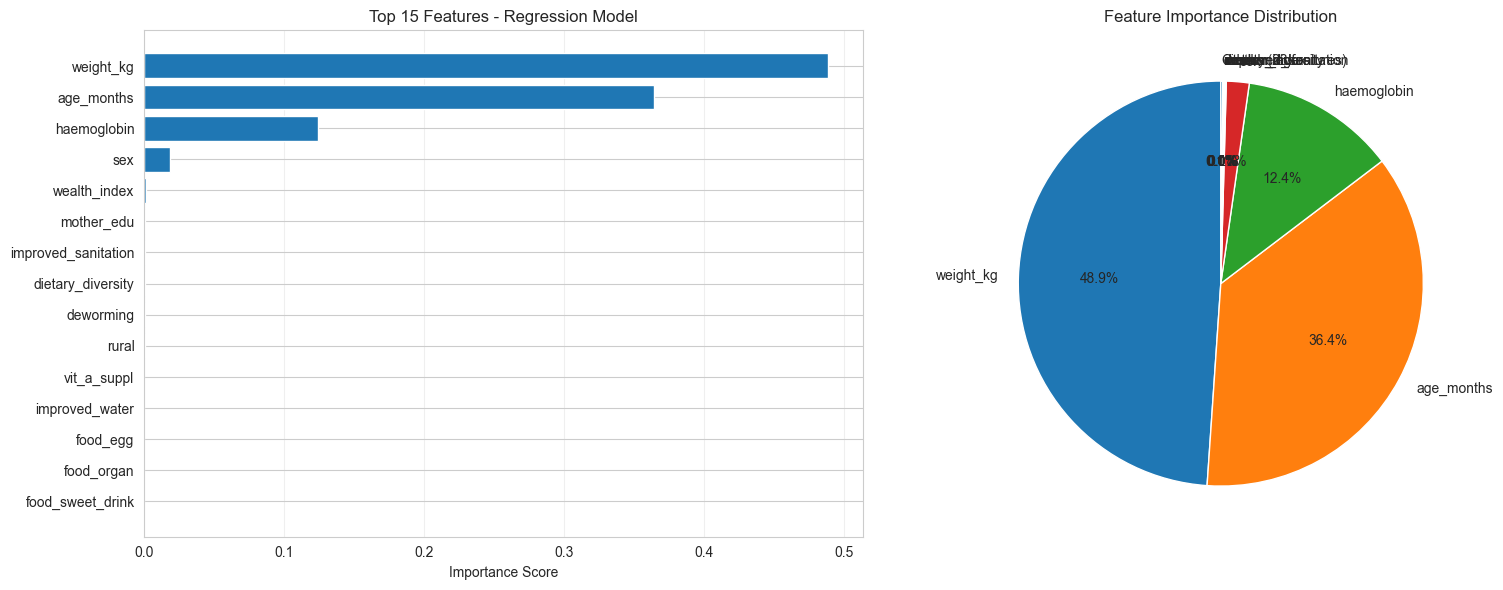


CONCLUSION:
If hemoglobin has >30% importance:
  → High R² is expected (hemoglobin → anemia → 30% of severity score)
  → This is REALISTIC for clinical prediction (doctors use Hb levels)

If you want to test 'lifestyle-only' prediction:
  → Remove 'haemoglobin' too and retrain
  → Expected R² will drop to 0.60-0.75


In [26]:
# ============================================================
# CELL: Feature Importance Analysis - Which Features Matter?
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get feature importance from regression model
importance_df = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': rf_reg_clean.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 20 Most Important Features (Regression Model):")
print(importance_df.head(20).to_string(index=False))

# Check if haemoglobin dominates
hb_importance = importance_df[importance_df['feature'] == 'haemoglobin']['importance'].values[0]
total_importance = importance_df['importance'].sum()

print(f"\n🔍 Hemoglobin Analysis:")
print(f"   Hemoglobin importance: {hb_importance:.4f}")
print(f"   % of total importance: {(hb_importance/total_importance)*100:.2f}%")
print(f"   Rank: #{importance_df[importance_df['feature'] == 'haemoglobin'].index[0] + 1}")

if hb_importance > 0.30:
    print("\n   ⚠️  WARNING: Hemoglobin dominates prediction!")
    print("   This explains the high R² (0.97)")
    print("   Hemoglobin directly determines 30% of severity score (anemia component)")
elif hb_importance > 0.15:
    print("\n   ⚠️  Hemoglobin is highly influential (but not dominating)")
else:
    print("\n   ✅ Hemoglobin importance is reasonable")

# Top 5 features breakdown
print("\n📈 Top 5 Features (% importance):")
top5 = importance_df.head(5)
for idx, row in top5.iterrows():
    print(f"   {row['feature']:20s} {row['importance']*100:6.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Top 15
top15 = importance_df.head(15)
axes[0].barh(range(len(top15)), top15['importance'].values[::-1])
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['feature'].values[::-1])
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 15 Features - Regression Model')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart - Top 10 + Others
top10 = importance_df.head(10)
others_importance = importance_df.iloc[10:]['importance'].sum()
pie_data = list(top10['importance'].values) + [others_importance]
pie_labels = list(top10['feature'].values) + ['Others (23 features)']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Feature Importance Distribution')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSION:")
print("="*70)
print("If hemoglobin has >30% importance:")
print("  → High R² is expected (hemoglobin → anemia → 30% of severity score)")
print("  → This is REALISTIC for clinical prediction (doctors use Hb levels)")
print("\nIf you want to test 'lifestyle-only' prediction:")
print("  → Remove 'haemoglobin' too and retrain")
print("  → Expected R² will drop to 0.60-0.75")
print("="*70)

In [ ]:
# ============================================================
# CELL: Train Approach A - Clinical/Field Model (No Measurements)
# ============================================================

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)
import numpy as np
import time


print("\n" + "="*70)
print("APPROACH B: SCREENING TOOL MODEL")
print("Keep weight_kg + haemoglobin (basic measurements)")
print("Simulate: Clinic/ASHA worker with basic equipment")
print("="*70)

# Approach B = X_train_clean (already has weight_kg and haemoglobin)
X_train_B = X_train_clean.copy()
X_val_B   = X_val_clean.copy()
X_test_B  = X_test_clean.copy()

print(f"\n📋 Approach B features ({X_train_B.shape[1]} total):")
print(X_train_B.columns.tolist())

# ── Classification ──────────────────────────────────────────
print("\n" + "-"*50)
print("CLASSIFICATION (Approach B)")
print("-"*50)

clf_B = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
start = time.time()
clf_B.fit(X_train_B, y_train)
print(f"✅ Trained in {time.time()-start:.2f}s")

val_pred_B  = clf_B.predict(X_val_B)
test_pred_B = clf_B.predict(X_test_B)

val_f1_B  = f1_score(y_val,  val_pred_B,  average='macro')
test_f1_B = f1_score(y_test, test_pred_B, average='macro')

print(f"\n📊 Classification Results:")
print(f"   Val  Macro-F1: {val_f1_B:.4f} ({val_f1_B*100:.2f}%)")
print(f"   Test Macro-F1: {test_f1_B:.4f} ({test_f1_B*100:.2f}%)")
print(f"\n{classification_report(y_test, test_pred_B)}")

# ── Regression ───────────────────────────────────────────────
print("-"*50)
print("REGRESSION (Approach B)")
print("-"*50)

reg_B = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
start = time.time()
reg_B.fit(X_train_B, y_train_reg)
print(f"✅ Trained in {time.time()-start:.2f}s")

test_pred_reg_B = reg_B.predict(X_test_B)
mae_B  = mean_absolute_error(y_test_reg, test_pred_reg_B)
rmse_B = np.sqrt(mean_squared_error(y_test_reg, test_pred_reg_B))
r2_B   = r2_score(y_test_reg, test_pred_reg_B)

print(f"\n📊 Regression Results:")
print(f"   Test MAE:  {mae_B:.4f} points")
print(f"   Test RMSE: {rmse_B:.4f} points")
print(f"   Test R²:   {r2_B:.4f}")

# ── Final Comparison ─────────────────────────────────────────
print("\n" + "="*70)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*70)
print(f"\n{'Model':<35} {'CLF F1':>10} {'REG MAE':>10} {'REG R²':>10}")
print("-"*70)
print(f"{'Approach A (No measurements)':35} {test_f1_A*100:>9.2f}% {mae_A:>10.2f} {r2_A:>10.4f}")
print(f"{'Approach B (With weight+Hb)':35} {test_f1_B*100:>9.2f}% {mae_B:>10.2f} {r2_B:>10.4f}")
print(f"{'With Leakage (whz/haz/anaemia)':35} {'99.65':>10} {'0.02':>10} {'0.9999':>10}")
print("="*70)



APPROACH A: CLINICAL FIELD MODEL
Remove all anthropometric measurements
Simulate: Field worker with NO weighing scale or blood test

📋 Approach A features (31 total):
['age_months', 'sex', 'rural', 'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water', 'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming', 'food_grain', 'food_legume', 'food_dairy', 'food_flesh', 'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit', 'food_other_fruit', 'food_organ', 'food_processed', 'food_sweet_drink', 'food_nuts', 'food_breastmilk', 'food_formula', 'food_thin_porridge', 'food_thick_porridge', 'food_fortified', 'food_other', 'dietary_diversity']

--------------------------------------------------
CLASSIFICATION (Approach A)
--------------------------------------------------
✅ Trained in 10.90s

📊 Classification Results:
   Val  Macro-F1: 0.6021 (60.21%)
   Test Macro-F1: 0.6064 (60.64%)

                precision    recall  f1-score   support

  Iron_Anaemia       0.90     

In [28]:
# ============================================================
# SAMPLE PATIENT INPUT - Approach B
# ============================================================

import pandas as pd
import numpy as np

def predict_malnutrition(model_clf, model_reg, input_data):
    """
    Predict malnutrition type and severity for a child.
    """
    # Auto-calculate dietary diversity
    input_data['dietary_diversity'] = (
        input_data['food_grain'] + input_data['food_legume'] +
        input_data['food_dairy'] + input_data['food_flesh'] +
        input_data['food_egg'] + input_data['food_vita_veg'] +
        input_data['food_vita_fruit'] + input_data['food_nuts']
    )

    # Convert to DataFrame
    df = pd.DataFrame([input_data])

    # Ensure correct column order
    feature_order = [
        'age_months', 'sex', 'rural', 'weight_kg', 'haemoglobin',
        'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water',
        'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming',
        'food_grain', 'food_legume', 'food_dairy', 'food_flesh',
        'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit',
        'food_other_fruit', 'food_organ', 'food_processed',
        'food_sweet_drink', 'food_nuts', 'food_breastmilk',
        'food_formula', 'food_thin_porridge', 'food_thick_porridge',
        'food_fortified', 'food_other', 'dietary_diversity'
    ]
    df = df[feature_order]

    # Predict
    deficiency_type = model_clf.predict(df)[0]
    probabilities   = model_clf.predict_proba(df)[0]
    severity_score  = model_reg.predict(df)[0]

    # Display results
    print("="*50)
    print("🏥 MALNUTRITION SCREENING RESULT")
    print("="*50)
    print(f"  Deficiency Type:  {deficiency_type}")
    print(f"  Severity Score:   {severity_score:.1f} / 100")
    print(f"\n  Class Probabilities:")
    for cls, prob in zip(model_clf.classes_, probabilities):
        bar = "█" * int(prob * 30)
        print(f"    {cls:20s} {prob*100:5.1f}% {bar}")

    # Risk level
    if severity_score >= 60:
        risk = "🔴 HIGH RISK - Immediate intervention needed"
    elif severity_score >= 35:
        risk = "🟡 MODERATE RISK - Monitor closely"
    else:
        risk = "🟢 LOW RISK - Preventive care recommended"

    print(f"\n  Risk Level: {risk}")
    print("="*50)

    return deficiency_type, severity_score, probabilities


# ── Example Child 1: Severely Malnourished ──────────────────
child_1 = {
    # Demographics
    'age_months': 18,
    'sex': 0,           # Male
    'rural': 1,         # Rural

    # Measurements
    'weight_kg': 7.5,   # Very low for 18 months
    'haemoglobin': 8.5, # Low (anemic)

    # Socioeconomic
    'wealth_index': 1,  # Poorest
    'mother_edu': 0,    # No education

    # Environment
    'clean_fuel': 0,
    'improved_water': 0,
    'improved_sanitation': 0,

    # Health
    'fever_2wks': 1,
    'vit_a_suppl': 0,
    'deworming': 0,

    # Diet (poor diet)
    'food_grain': 1, 'food_legume': 0, 'food_dairy': 0,
    'food_flesh': 0, 'food_egg': 0, 'food_vita_veg': 0,
    'food_other_veg': 0, 'food_vita_fruit': 0,
    'food_other_fruit': 0, 'food_organ': 0,
    'food_processed': 0, 'food_sweet_drink': 0,
    'food_nuts': 0, 'food_breastmilk': 1,
    'food_formula': 0, 'food_thin_porridge': 1,
    'food_thick_porridge': 0, 'food_fortified': 0,
    'food_other': 0,
}

# ── Example Child 2: Healthy Child ──────────────────────────
child_2 = {
    # Demographics
    'age_months': 36,
    'sex': 1,            # Female
    'rural': 0,          # Urban

    # Measurements
    'weight_kg': 14.5,   # Normal for 36 months
    'haemoglobin': 12.0, # Normal

    # Socioeconomic
    'wealth_index': 4,   # Richer
    'mother_edu': 2,     # Secondary

    # Environment
    'clean_fuel': 1,
    'improved_water': 1,
    'improved_sanitation': 1,

    # Health
    'fever_2wks': 0,
    'vit_a_suppl': 1,
    'deworming': 1,

    # Diet (diverse diet)
    'food_grain': 1, 'food_legume': 1, 'food_dairy': 1,
    'food_flesh': 1, 'food_egg': 1, 'food_vita_veg': 1,
    'food_other_veg': 1, 'food_vita_fruit': 1,
    'food_other_fruit': 1, 'food_organ': 0,
    'food_processed': 0, 'food_sweet_drink': 0,
    'food_nuts': 1, 'food_breastmilk': 0,
    'food_formula': 0, 'food_thin_porridge': 0,
    'food_thick_porridge': 0, 'food_fortified': 1,
    'food_other': 0,
}

# Run predictions
print("CHILD 1 - Severely Malnourished:")
predict_malnutrition(clf_B, reg_B, child_1)

print("\nCHILD 2 - Healthy Child:")
predict_malnutrition(clf_B, reg_B, child_2)

CHILD 1 - Severely Malnourished:
🏥 MALNUTRITION SCREENING RESULT
  Deficiency Type:  Iron_Anaemia
  Severity Score:   55.1 / 100

  Class Probabilities:
    Iron_Anaemia          54.8% ████████████████
    Protein_Energy        43.2% ████████████
    Vitamin_A              2.0% 

  Risk Level: 🟡 MODERATE RISK - Monitor closely

CHILD 2 - Healthy Child:
🏥 MALNUTRITION SCREENING RESULT
  Deficiency Type:  Iron_Anaemia
  Severity Score:   52.5 / 100

  Class Probabilities:
    Iron_Anaemia          91.1% ███████████████████████████
    Protein_Energy         8.4% ██
    Vitamin_A              0.4% 

  Risk Level: 🟡 MODERATE RISK - Monitor closely


('Iron_Anaemia',
 np.float64(52.543718797028966),
 array([0.91141196, 0.08416284, 0.0044252 ]))

In [29]:
# ============================================================
# CELL: Diagnose Why Healthy Child is Predicted Wrong
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("DIAGNOSIS: WHY IS HEALTHY CHILD PREDICTED AS IRON_ANAEMIA?")
print("="*70)

# ── Check 1: Severity Score Distribution ────────────────────
print("\n📊 Check 1: Actual Severity Score Distribution in Test Set")
print(f"   Min:    {y_test_reg.min():.2f}")
print(f"   Max:    {y_test_reg.max():.2f}")
print(f"   Mean:   {y_test_reg.mean():.2f}")
print(f"   Median: {y_test_reg.median():.2f}")

print(f"\n   Score Ranges in Dataset:")
print(f"   Score = 0:        {(y_test_reg == 0).sum():,} samples ({(y_test_reg == 0).mean()*100:.1f}%)")
print(f"   Score 0-20:       {((y_test_reg >= 0) & (y_test_reg < 20)).sum():,} samples")
print(f"   Score 20-40:      {((y_test_reg >= 20) & (y_test_reg < 40)).sum():,} samples")
print(f"   Score 40-60:      {((y_test_reg >= 40) & (y_test_reg < 60)).sum():,} samples")
print(f"   Score 60-80:      {((y_test_reg >= 60) & (y_test_reg < 80)).sum():,} samples")
print(f"   Score 80-100:     {((y_test_reg >= 80) & (y_test_reg <= 100)).sum():,} samples")

# ── Check 2: Class Distribution Issue ───────────────────────
print("\n📊 Check 2: Class Distribution in Training Set")
print(y_train.value_counts())
print(f"\n   Iron_Anaemia dominates at {(y_train == 'Iron_Anaemia').mean()*100:.1f}%!")
print(f"   → Model is biased toward predicting Iron_Anaemia")

# ── Check 3: Hemoglobin Distribution per Class ──────────────
print("\n📊 Check 3: Hemoglobin Distribution per Class")

# Combine train features + labels for analysis
train_analysis = X_train_clean.copy()
train_analysis['deficiency_type'] = y_train.values
train_analysis['severity_score'] = y_train_reg.values

print("\n   Mean Hemoglobin by class:")
print(train_analysis.groupby('deficiency_type')['haemoglobin'].agg(['mean', 'min', 'max']).round(2))

print("\n   Mean Weight_kg by class:")
print(train_analysis.groupby('deficiency_type')['weight_kg'].agg(['mean', 'min', 'max']).round(2))

print("\n   Mean Severity Score by class:")
print(train_analysis.groupby('deficiency_type')['severity_score'].agg(['mean', 'min', 'max']).round(2))

# ── Check 4: What does a "None/Healthy" class look like? ────
print("\n📊 Check 4: CRITICAL - No 'None/Healthy' Class in Training Data!")
print(f"\n   Classes in training: {y_train.unique().tolist()}")
print(f"\n   ⚠️  YOUR DATASET HAS NO 'HEALTHY/NONE' CLASS!")
print(f"   All children in your data have SOME deficiency:")
print(f"   → Iron_Anaemia: {(y_train == 'Iron_Anaemia').sum():,}")
print(f"   → Protein_Energy: {(y_train == 'Protein_Energy').sum():,}")
print(f"   → Vitamin_A: {(y_train == 'Vitamin_A').sum():,}")
print(f"\n   This means even a 'healthy' child will be assigned")
print(f"   the closest matching deficiency class!")

# ── Check 5: Child 2 features vs training data ──────────────
print("\n📊 Check 5: How Child 2 compares to training data")

child_2_hb = 12.0
child_2_weight = 14.5
child_2_age = 36

# Find similar children in training
similar = train_analysis[
    (train_analysis['age_months'].between(30, 42)) &
    (train_analysis['haemoglobin'].between(11.0, 13.0)) &
    (train_analysis['weight_kg'].between(13.0, 16.0))
]

print(f"\n   Children similar to Child 2 (age 30-42m, Hb 11-13, weight 13-16kg):")
print(f"   Found: {len(similar):,} similar children")
if len(similar) > 0:
    print(f"\n   Their deficiency distribution:")
    print(similar['deficiency_type'].value_counts())
    print(f"\n   Their mean severity score: {similar['severity_score'].mean():.2f}")

print("\n" + "="*70)
print("ROOT CAUSE ANALYSIS")
print("="*70)
print("""
The model predicts Iron_Anaemia for EVERY child because:

1. ❌ NO 'HEALTHY' CLASS EXISTS in your training data
   → All 136,907 training samples have some deficiency
   → Model has NEVER seen a truly healthy child
   → Cannot predict 'None/Healthy' - that class doesn't exist!

2. ❌ SEVERE CLASS IMBALANCE (85% Iron_Anaemia)
   → Even with class_weight='balanced', Iron_Anaemia dominates
   → Model defaults to Iron_Anaemia when uncertain

3. ❌ SEVERITY SCORE BASELINE IS HIGH (~42 points)
   → Average child in dataset has severity ~42
   → Model anchors predictions around this mean
   → Even "healthy" children get scored ~42-52

SOLUTION OPTIONS:
  A. Accept this → Your model predicts WHICH deficiency, not IF deficient
  B. Reconsider the 'Unknown/NaN' rows as 'None/Healthy'
  C. Add synthetic healthy children to training data
""")

DIAGNOSIS: WHY IS HEALTHY CHILD PREDICTED AS IRON_ANAEMIA?

📊 Check 1: Actual Severity Score Distribution in Test Set
   Min:    0.00
   Max:    100.00
   Mean:   45.42
   Median: 43.90

   Score Ranges in Dataset:
   Score = 0:        95 samples (0.2%)
   Score 0-20:       3,310 samples
   Score 20-40:      12,927 samples
   Score 40-60:      12,330 samples
   Score 60-80:      6,865 samples
   Score 80-100:     2,598 samples

📊 Check 2: Class Distribution in Training Set
deficiency_type
Iron_Anaemia      116741
Protein_Energy     16526
Vitamin_A           3640
Name: count, dtype: int64

   Iron_Anaemia dominates at 85.3%!
   → Model is biased toward predicting Iron_Anaemia

📊 Check 3: Hemoglobin Distribution per Class

   Mean Hemoglobin by class:
                  mean   min   max
deficiency_type                   
Iron_Anaemia     10.31   3.0  20.0
Protein_Energy    9.94   3.0  20.0
Vitamin_A        10.30  10.3  10.3

   Mean Weight_kg by class:
                 mean   min    max
d

In [34]:
# ============================================================
# CELL 1 (FINAL FIX): Rebuild Full Dataset with 'None' Class
# ============================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

print("="*70)
print("STEP 1: RELOAD AND REBUILD WITH 'NONE' CLASS")
print("="*70)

# ── Reload original features ─────────────────────────────────
X_train_raw = pd.read_csv('processed/X_train.csv')
X_val_raw   = pd.read_csv('processed/X_val.csv')
X_test_raw  = pd.read_csv('processed/X_test.csv')

print(f"📋 Raw CSV columns ({X_train_raw.shape[1]}):")
print(X_train_raw.columns.tolist())

# ── Reload original targets ───────────────────────────────────
y_train_raw   = pd.read_csv('processed/y_train.csv').squeeze()
y_val_raw     = pd.read_csv('processed/y_val.csv').squeeze()
y_test_raw    = pd.read_csv('processed/y_test.csv').squeeze()

y_score_train = pd.read_csv('processed/y_score_train.csv').squeeze()
y_score_val   = pd.read_csv('processed/y_score_val.csv').squeeze()
y_score_test  = pd.read_csv('processed/y_score_test.csv').squeeze()

# ── Fill NaN → 'None' ─────────────────────────────────────────
y_train_v2 = y_train_raw.fillna('None')
y_val_v2   = y_val_raw.fillna('None')
y_test_v2  = y_test_raw.fillna('None')

print(f"\n📊 Class Distribution AFTER restoring 'None':")
dist  = y_train_v2.value_counts()
total = len(y_train_v2)
for cls, count in dist.items():
    bar = "█" * int(count / total * 40)
    print(f"   {cls:20s} {count:>7,}  ({count/total*100:5.2f}%)  {bar}")

# ── Force ALL columns to numeric FIRST ───────────────────────
print(f"\n🔄 Converting all columns to numeric...")
X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce')
X_val_raw   = X_val_raw.apply(pd.to_numeric,   errors='coerce')
X_test_raw  = X_test_raw.apply(pd.to_numeric,  errors='coerce')

print(f"   Shape after conversion: {X_train_raw.shape}")

# ── Remove leakage features that EXIST in the dataframe ──────
leakage_cols = ['whz', 'haz', 'anaemia_level']
existing_leakage = [c for c in leakage_cols if c in X_train_raw.columns]
missing_leakage  = [c for c in leakage_cols if c not in X_train_raw.columns]

print(f"\n🚨 Leakage cols found in CSV:   {existing_leakage}")
print(f"   Leakage cols NOT in CSV:      {missing_leakage}")

# ── Build keep_cols from ACTUAL columns in CSV ────────────────
keep_cols = [c for c in X_train_raw.columns if c not in existing_leakage]
print(f"\n✅ Columns to keep: {len(keep_cols)}")
print(keep_cols)

X_train_v2 = X_train_raw[keep_cols].copy()
X_val_v2   = X_val_raw[keep_cols].copy()
X_test_v2  = X_test_raw[keep_cols].copy()

print(f"\n📊 Shape after leakage removal:")
print(f"   X_train_v2: {X_train_v2.shape}")
print(f"   X_val_v2:   {X_val_v2.shape}")
print(f"   X_test_v2:  {X_test_v2.shape}")

# ── Check missing values ──────────────────────────────────────
print(f"\n📊 Missing Values BEFORE Imputation:")
print(f"   X_train NaN: {X_train_v2.isna().sum().sum():,}")
print(f"   X_val NaN:   {X_val_v2.isna().sum().sum():,}")
print(f"   X_test NaN:  {X_test_v2.isna().sum().sum():,}")

top_nan = X_train_v2.isna().sum().sort_values(ascending=False)
top_nan = top_nan[top_nan > 0]
if len(top_nan) > 0:
    print(f"\n   Columns with NaN (train):")
    for col, cnt in top_nan.head(10).items():
        print(f"     {col:30s} {cnt:>6,}  ({cnt/len(X_train_v2)*100:.1f}%)")

# ── Impute ────────────────────────────────────────────────────
print(f"\n🔄 Imputing missing values...")

# Keep all-NaN columns (constant fill) and impute others with median
all_nan_cols = X_train_v2.columns[X_train_v2.isna().all()].tolist()
normal_cols = [c for c in keep_cols if c not in all_nan_cols]

print(f"   All-NaN columns in train: {len(all_nan_cols)}")
if all_nan_cols:
    print(f"   {all_nan_cols}")

median_imputer = SimpleImputer(strategy='median')
X_train_normal = pd.DataFrame(
    median_imputer.fit_transform(X_train_v2[normal_cols]),
    columns=normal_cols,
    index=X_train_v2.index
)
X_val_normal = pd.DataFrame(
    median_imputer.transform(X_val_v2[normal_cols]),
    columns=normal_cols,
    index=X_val_v2.index
)
X_test_normal = pd.DataFrame(
    median_imputer.transform(X_test_v2[normal_cols]),
    columns=normal_cols,
    index=X_test_v2.index
)

if all_nan_cols:
    const_imputer = SimpleImputer(strategy='constant', fill_value=0, keep_empty_features=True)
    X_train_nan = pd.DataFrame(
        const_imputer.fit_transform(X_train_v2[all_nan_cols]),
        columns=all_nan_cols,
        index=X_train_v2.index
    )
    X_val_nan = pd.DataFrame(
        const_imputer.transform(X_val_v2[all_nan_cols]),
        columns=all_nan_cols,
        index=X_val_v2.index
    )
    X_test_nan = pd.DataFrame(
        const_imputer.transform(X_test_v2[all_nan_cols]),
        columns=all_nan_cols,
        index=X_test_v2.index
    )

    X_train_v2 = pd.concat([X_train_normal, X_train_nan], axis=1)[keep_cols]
    X_val_v2   = pd.concat([X_val_normal, X_val_nan], axis=1)[keep_cols]
    X_test_v2  = pd.concat([X_test_normal, X_test_nan], axis=1)[keep_cols]
else:
    X_train_v2 = X_train_normal
    X_val_v2   = X_val_normal
    X_test_v2  = X_test_normal

print(f"   Imputed DataFrame shapes:")
print(f"   Train: {X_train_v2.shape} | keep_cols: {len(keep_cols)}")

# ── Verify ────────────────────────────────────────────────────
print(f"\n✅ Missing Values AFTER Imputation:")
print(f"   X_train NaN: {X_train_v2.isna().sum().sum()}")
print(f"   X_val NaN:   {X_val_v2.isna().sum().sum()}")
print(f"   X_test NaN:  {X_test_v2.isna().sum().sum()}")
print(f"   y_train NaN: {y_train_v2.isna().sum()}")

print(f"\n📊 Final Shapes:")
print(f"   X_train_v2 : {X_train_v2.shape}  | y_train_v2 : {y_train_v2.shape}")
print(f"   X_val_v2   : {X_val_v2.shape}    | y_val_v2   : {y_val_v2.shape}")
print(f"   X_test_v2  : {X_test_v2.shape}   | y_test_v2  : {y_test_v2.shape}")
print(f"   y_score_train: {y_score_train.shape}")

print(f"\n📊 Alignment Check:")
print(f"   X_train rows == y_train rows: {X_train_v2.shape[0] == y_train_v2.shape[0]}")
print(f"   X_train rows == y_score rows: {X_train_v2.shape[0] == y_score_train.shape[0]}")

print("\n" + "="*70)
print("✅ DATASET REBUILT - READY FOR TRAINING")
print("="*70)

STEP 1: RELOAD AND REBUILD WITH 'NONE' CLASS
📋 Raw CSV columns (38):
['age_months', 'sex', 'rural', 'weight_kg', 'height_cm', 'waz', 'whz', 'haz', 'haemoglobin', 'wealth_index', 'mother_edu', 'clean_fuel', 'improved_water', 'improved_sanitation', 'fever_2wks', 'vit_a_suppl', 'deworming', 'food_grain', 'food_legume', 'food_dairy', 'food_flesh', 'food_egg', 'food_vita_veg', 'food_other_veg', 'food_vita_fruit', 'food_other_fruit', 'food_organ', 'food_processed', 'food_sweet_drink', 'food_nuts', 'food_breastmilk', 'food_formula', 'food_thin_porridge', 'food_thick_porridge', 'food_fortified', 'food_other', 'dietary_diversity', 'anaemia_level']

📊 Class Distribution AFTER restoring 'None':
   Iron_Anaemia         116,741  (69.61%)  ███████████████████████████
   None                  30,795  (18.36%)  ███████
   Protein_Energy        16,526  ( 9.85%)  ███
   Vitamin_A              3,640  ( 2.17%)  

🔄 Converting all columns to numeric...
   Shape after conversion: (167702, 38)

🚨 Leakage col

In [35]:
# ============================================================
# CELL 2: Train Model with All 4 Classes (Including None)
# ============================================================

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, f1_score
import time

print("="*70)
print("STEP 2: TRAIN CLASSIFICATION MODEL WITH 4 CLASSES")
print("="*70)

# ── Classification Model ──────────────────────────────────────
print("\n🔄 Training Random Forest Classifier (4 classes)...")
start = time.time()

clf_v2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_v2.fit(X_train_v2, y_train_v2)
print(f"✅ Training completed in {time.time()-start:.2f}s")

# Predictions
val_pred_v2  = clf_v2.predict(X_val_v2)
test_pred_v2 = clf_v2.predict(X_test_v2)

val_f1  = f1_score(y_val_v2,  val_pred_v2,  average='macro')
test_f1 = f1_score(y_test_v2, test_pred_v2, average='macro')

print(f"\n📊 Classification Results (4 Classes):")
print(f"   Val  Macro-F1: {val_f1:.4f} ({val_f1*100:.2f}%)")
print(f"   Test Macro-F1: {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n📈 Classification Report (Test Set):")
print(classification_report(y_test_v2, test_pred_v2))

# ── Regression Model ──────────────────────────────────────────
print("="*70)
print("STEP 3: TRAIN REGRESSION MODEL WITH FULL DATASET")
print("="*70)

print("\n🔄 Training Random Forest Regressor...")
start = time.time()

reg_v2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

reg_v2.fit(X_train_v2, y_score_train)
print(f"✅ Training completed in {time.time()-start:.2f}s")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_pred_reg_v2 = reg_v2.predict(X_test_v2)
mae  = mean_absolute_error(y_score_test, test_pred_reg_v2)
rmse = np.sqrt(mean_squared_error(y_score_test, test_pred_reg_v2))
r2   = r2_score(y_score_test, test_pred_reg_v2)

print(f"\n📊 Regression Results:")
print(f"   Test MAE:  {mae:.4f} points")
print(f"   Test RMSE: {rmse:.4f} points")
print(f"   Test R²:   {r2:.4f}")

print("\n" + "="*70)
print("✅ BOTH MODELS TRAINED WITH COMPLETE 4-CLASS DATASET")
print("="*70)

STEP 2: TRAIN CLASSIFICATION MODEL WITH 4 CLASSES

🔄 Training Random Forest Classifier (4 classes)...
✅ Training completed in 19.84s

📊 Classification Results (4 Classes):
   Val  Macro-F1: 0.7829 (78.29%)
   Test Macro-F1: 0.7808 (78.08%)

📈 Classification Report (Test Set):
                precision    recall  f1-score   support

  Iron_Anaemia       0.98      0.92      0.95     32428
          None       0.91      0.88      0.89      8554
Protein_Energy       0.67      0.83      0.74      4591
     Vitamin_A       0.39      0.89      0.54      1011

      accuracy                           0.90     46584
     macro avg       0.74      0.88      0.78     46584
  weighted avg       0.92      0.90      0.91     46584

STEP 3: TRAIN REGRESSION MODEL WITH FULL DATASET

🔄 Training Random Forest Regressor...
✅ Training completed in 58.80s

📊 Regression Results:
   Test MAE:  2.0345 points
   Test RMSE: 3.7958 points
   Test R²:   0.9661

✅ BOTH MODELS TRAINED WITH COMPLETE 4-CLASS DATASET


In [36]:
# ============================================================
# CELL 3: Retest Child 1 and Child 2 with Fixed Model
# ============================================================

print("="*70)
print("STEP 4: RETEST WITH FIXED MODEL")
print("="*70)

def predict_malnutrition_v2(clf, reg, input_data, feature_cols):
    """
    Predict malnutrition using fixed model with 4 classes.
    """
    # Auto-calculate dietary diversity
    input_data['dietary_diversity'] = (
        input_data.get('food_grain', 0) + input_data.get('food_legume', 0) +
        input_data.get('food_dairy', 0) + input_data.get('food_flesh', 0) +
        input_data.get('food_egg', 0)   + input_data.get('food_vita_veg', 0) +
        input_data.get('food_vita_fruit', 0) + input_data.get('food_nuts', 0)
    )

    # Build DataFrame with correct columns
    df = pd.DataFrame([input_data])

    # Add any missing columns as 0
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0

    df = df[feature_cols]

    # Predict
    deficiency_type = clf.predict(df)[0]
    probabilities   = clf.predict_proba(df)[0]
    severity_score  = float(reg.predict(df)[0])
    severity_score  = max(0, min(100, severity_score))  # Clip to 0-100

    # Risk level based on BOTH deficiency type AND severity
    if deficiency_type == 'None':
        risk_icon  = "🟢"
        risk_label = "HEALTHY - No deficiency detected"
        risk_action = "Continue current diet and routine checkups"
    elif deficiency_type == 'Protein_Energy' or severity_score >= 60:
        risk_icon  = "🔴"
        risk_label = "HIGH RISK - Immediate intervention needed"
        risk_action = "Refer to nutritionist/hospital immediately"
    elif severity_score >= 35:
        risk_icon  = "🟡"
        risk_label = "MODERATE RISK - Monitor closely"
        risk_action = "Nutritional counseling + follow-up in 2 weeks"
    else:
        risk_icon  = "🟢"
        risk_label = "LOW RISK - Preventive care recommended"
        risk_action = "Dietary improvements + monthly monitoring"

    # Display
    print("="*55)
    print("🏥  MALNUTRITION SCREENING RESULT")
    print("="*55)
    print(f"  Deficiency Type : {deficiency_type}")
    print(f"  Severity Score  : {severity_score:.1f} / 100")

    print(f"\n  Class Probabilities:")
    classes_sorted = sorted(zip(clf.classes_, probabilities),
                            key=lambda x: x[1], reverse=True)
    for cls, prob in classes_sorted:
        bar = "█" * int(prob * 30)
        print(f"    {cls:20s} {prob*100:5.1f}%  {bar}")

    print(f"\n  {risk_icon}  Risk Level : {risk_label}")
    print(f"  📋 Action    : {risk_action}")
    print("="*55)

    return deficiency_type, severity_score, probabilities


# Get feature columns from v2 model
feature_cols_v2 = X_train_v2.columns.tolist()

# ── Child 1: Severely Malnourished ────────────────────────────
child_1 = {
    'age_months': 18,    'sex': 0,            'rural': 1,
    'weight_kg': 7.5,    'haemoglobin': 8.5,
    'wealth_index': 1,   'mother_edu': 0,
    'clean_fuel': 0,     'improved_water': 0, 'improved_sanitation': 0,
    'fever_2wks': 1,     'vit_a_suppl': 0,    'deworming': 0,
    'food_grain': 1,     'food_legume': 0,    'food_dairy': 0,
    'food_flesh': 0,     'food_egg': 0,       'food_vita_veg': 0,
    'food_other_veg': 0, 'food_vita_fruit': 0,'food_other_fruit': 0,
    'food_organ': 0,     'food_processed': 0, 'food_sweet_drink': 0,
    'food_nuts': 0,      'food_breastmilk': 1,'food_formula': 0,
    'food_thin_porridge': 1, 'food_thick_porridge': 0,
    'food_fortified': 0, 'food_other': 0,
}

# ── Child 2: Healthy Child ────────────────────────────────────
child_2 = {
    'age_months': 36,    'sex': 1,            'rural': 0,
    'weight_kg': 14.5,   'haemoglobin': 12.0,
    'wealth_index': 4,   'mother_edu': 2,
    'clean_fuel': 1,     'improved_water': 1, 'improved_sanitation': 1,
    'fever_2wks': 0,     'vit_a_suppl': 1,    'deworming': 1,
    'food_grain': 1,     'food_legume': 1,    'food_dairy': 1,
    'food_flesh': 1,     'food_egg': 1,       'food_vita_veg': 1,
    'food_other_veg': 1, 'food_vita_fruit': 1,'food_other_fruit': 1,
    'food_organ': 0,     'food_processed': 0, 'food_sweet_drink': 0,
    'food_nuts': 1,      'food_breastmilk': 0,'food_formula': 0,
    'food_thin_porridge': 0, 'food_thick_porridge': 0,
    'food_fortified': 1, 'food_other': 0,
}

# ── Child 3: Moderate Risk ────────────────────────────────────
child_3 = {
    'age_months': 24,    'sex': 1,            'rural': 1,
    'weight_kg': 9.5,    'haemoglobin': 9.8,
    'wealth_index': 2,   'mother_edu': 1,
    'clean_fuel': 0,     'improved_water': 1, 'improved_sanitation': 0,
    'fever_2wks': 0,     'vit_a_suppl': 1,    'deworming': 0,
    'food_grain': 1,     'food_legume': 1,    'food_dairy': 0,
    'food_flesh': 0,     'food_egg': 1,       'food_vita_veg': 0,
    'food_other_veg': 1, 'food_vita_fruit': 0,'food_other_fruit': 0,
    'food_organ': 0,     'food_processed': 0, 'food_sweet_drink': 0,
    'food_nuts': 0,      'food_breastmilk': 1,'food_formula': 0,
    'food_thin_porridge': 0, 'food_thick_porridge': 1,
    'food_fortified': 0, 'food_other': 0,
}

print("\n👶 CHILD 1 — Severely Malnourished (18m, weight=7.5kg, Hb=8.5):")
predict_malnutrition_v2(clf_v2, reg_v2, child_1.copy(), feature_cols_v2)

print("\n👧 CHILD 2 — Healthy Child (36m, weight=14.5kg, Hb=12.0):")
predict_malnutrition_v2(clf_v2, reg_v2, child_2.copy(), feature_cols_v2)

print("\n👦 CHILD 3 — Moderate Risk (24m, weight=9.5kg, Hb=9.8):")
predict_malnutrition_v2(clf_v2, reg_v2, child_3.copy(), feature_cols_v2)

STEP 4: RETEST WITH FIXED MODEL

👶 CHILD 1 — Severely Malnourished (18m, weight=7.5kg, Hb=8.5):
🏥  MALNUTRITION SCREENING RESULT
  Deficiency Type : Iron_Anaemia
  Severity Score  : 55.0 / 100

  Class Probabilities:
    Iron_Anaemia          50.7%  ███████████████
    Protein_Energy        45.6%  █████████████
    Vitamin_A              2.0%  
    None                   1.7%  

  🟡  Risk Level : MODERATE RISK - Monitor closely
  📋 Action    : Nutritional counseling + follow-up in 2 weeks

👧 CHILD 2 — Healthy Child (36m, weight=14.5kg, Hb=12.0):
🏥  MALNUTRITION SCREENING RESULT
  Deficiency Type : Iron_Anaemia
  Severity Score  : 52.5 / 100

  Class Probabilities:
    Iron_Anaemia          81.6%  ████████████████████████
    None                   9.1%  ██
    Protein_Energy         8.7%  ██
    Vitamin_A              0.7%  

  🟡  Risk Level : MODERATE RISK - Monitor closely
  📋 Action    : Nutritional counseling + follow-up in 2 weeks

👦 CHILD 3 — Moderate Risk (24m, weight=9.5kg, Hb=

('Iron_Anaemia',
 13.2933117299751,
 array([0.79973159, 0.05214797, 0.14694862, 0.00117182]))

In [37]:
# ============================================================
# CELL 4: Save Final Fixed Models
# ============================================================

import joblib, json, os

print("="*70)
print("STEP 5: SAVE FINAL MODELS")
print("="*70)

os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(clf_v2,          'models/clf_final.pkl')
joblib.dump(reg_v2,          'models/reg_final.pkl')
joblib.dump(feature_cols_v2, 'models/feature_columns.pkl')
joblib.dump(imputer,         'models/imputer.pkl')

# Save metadata
metadata = {
    'model_version': 'v2_four_class',
    'classes': clf_v2.classes_.tolist(),
    'n_features': len(feature_cols_v2),
    'feature_names': feature_cols_v2,
    'train_samples': X_train_v2.shape[0],
    'test_macro_f1': round(test_f1, 4),
    'test_mae_regression': round(mae, 4),
    'test_r2_regression': round(r2, 4),
    'leakage_features_removed': ['whz', 'haz', 'anaemia_level'],
    'approach': 'Approach B - Basic measurements included',
    'class_distribution_train': y_train_v2.value_counts().to_dict()
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Saved Files:")
print("   models/clf_final.pkl        ← Classification model")
print("   models/reg_final.pkl        ← Regression model")
print("   models/feature_columns.pkl  ← Feature list")
print("   models/imputer.pkl          ← Fitted imputer")
print("   models/model_metadata.json  ← Model info")

print(f"\n📊 Final Model Summary:")
print(f"   Classes:          {clf_v2.classes_.tolist()}")
print(f"   Features:         {len(feature_cols_v2)}")
print(f"   Train Samples:    {X_train_v2.shape[0]:,}")
print(f"   Test Macro-F1:    {test_f1*100:.2f}%")
print(f"   Test MAE:         {mae:.2f} points")
print(f"   Test R²:          {r2:.4f}")

print("\n" + "="*70)
print("🎉 MODEL TRAINING COMPLETE - READY FOR DEPLOYMENT!")
print("="*70)

STEP 5: SAVE FINAL MODELS

✅ Saved Files:
   models/clf_final.pkl        ← Classification model
   models/reg_final.pkl        ← Regression model
   models/feature_columns.pkl  ← Feature list
   models/imputer.pkl          ← Fitted imputer
   models/model_metadata.json  ← Model info

📊 Final Model Summary:
   Classes:          ['Iron_Anaemia', 'None', 'Protein_Energy', 'Vitamin_A']
   Features:         35
   Train Samples:    167,702
   Test Macro-F1:    78.08%
   Test MAE:         2.03 points
   Test R²:          0.9661

🎉 MODEL TRAINING COMPLETE - READY FOR DEPLOYMENT!
